<a href="https://colab.research.google.com/github/FaqihahSyazwani99/CL-Foreground-Segmentation-DINOv3/blob/main/Joint_UpperBound_full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Training a Foreground Segmentation Tool with DINOv3



### Setup

Let's start by loading some pre-requisites and checking the DINOv3 repository location:

In [3]:
# @title 1. Install Dependencies & Imports
!pip install -q roboflow torch torchvision tqdm matplotlib scikit-learn wandb torchmetrics

import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel
from google.colab import userdata, drive
from tqdm.notebook import tqdm
import random

print(" All dependencies installed and imported!")

 All dependencies installed and imported!


In [4]:
# @title 2. Mount Google Drive & Setup Paths
from google.colab import drive
import os

drive.mount('/content/drive')
print("✅ Google Drive mounted!")

# Define save paths for model weights
SAVED_WEIGHTS_PATH = '/content/drive/MyDrive/seg_head_weights.pth'
LOCAL_WEIGHTS_PATH = './seg_head_weights_local.pth'

# Create checkpoint directory (Updated to DINOv3)
checkpoint_dir = "/content/drive/MyDrive/DINOv3_Checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"Checkpoint directory: {checkpoint_dir}")

# Define Dataset Path directly to your EOR-Database folder
DATASET_PATH = '/content/drive/MyDrive/EOR-Database-MOT.v5-mot-rect-5-super-repairs-streched.coco-segmentation'
print(f"Dataset path set to: {DATASET_PATH}")

Mounted at /content/drive
✅ Google Drive mounted!
Checkpoint directory: /content/drive/MyDrive/DINOv3_Checkpoints
Dataset path set to: /content/drive/MyDrive/EOR-Database-MOT.v5-mot-rect-5-super-repairs-streched.coco-segmentation


In [5]:
# @title 2.5 Weights & Biases Setup with Secret Key
import wandb

# Initialize wandb (optional - you can skip if you don't want wandb)
USE_WANDB = True  # Set to False if you don't want wandb logging
wandb_run = None

if USE_WANDB:
    try:
        # Get wandb API key from Colab secrets
        wandb_api_key = userdata.get('WANDB_API')
        wandb.login(key=wandb_api_key)
        print(" WandB API key retrieved and logged in!")

        # Start a new run
        wandb.init(
            project="dino-foreground-segmentation",
            name="tao-dataset-training",
            config={
                "learning_rate": 1e-3,
                "batch_size": 1,
                "img_size": 448,
                "buffer_size": 50,
                "epochs": 1,
                "model": "DINOv3-ViT-L",
                "dataset": "TAO-Bin-Mask",
                "device" : torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                "optimizer": "Adam",
                "loss": "CrossEntropy"
            },
            resume="allow"
        )
        print("Weights & Biases initialized and run started!")

    except Exception as e:
        print(f" Error setting up WandB: {e}")
        print("  WandB logging disabled. Check your WANDB_API_KEY in secrets.")
        USE_WANDB = False
        wandb = None  # Set to None to avoid errors later
else:
    print("  WandB logging disabled by setting USE_WANDB=False.")
    wandb = None  # Set to None to avoid errors later

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: faqihahsyazwani23 (faqihahsyazwani23-university-malaya-medical-centre) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


 WandB API key retrieved and logged in!


Weights & Biases initialized and run started!


### Model & Head

Let's load the DINOv3 model. For this notebook, we will be using the ViT-L model, but if you have more or less hardware constraints, you can easily load any other DINOv3 model!

In [6]:
# @title 3. Load DINOv3 Model
try:
    hf_token = userdata.get('HF_TOKEN') # Make sure you added 'HF_TOKEN' to Colab Secrets!
    print("Token retrieved.")
except Exception as e:
    print("ERROR: Add 'HF_TOKEN' to the Key Icon on the left sidebar first!")
    raise e

# 2. Load DINOv3
print("Loading DINOv3 (ViT-L)...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_id = "facebook/dinov3-vitl16-pretrain-lvd1689m"

# AutoModel handles the download automatically using your token
model = AutoModel.from_pretrained(model_id, token=hf_token, trust_remote_code=True)
model.to(device)
model.eval()

# Freeze the backbone
for param in model.parameters():
    param.requires_grad = False

print(f"Model loaded and frozen!")

Token retrieved.
Loading DINOv3 (ViT-L)...


config.json:   0%|          | 0.00/745 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.21GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

Model loaded and frozen!


In [7]:
# @title 4. Define Multi-Class Segmentation Head
NUM_CLASSES = 6 # Update this based on how many defect types you have + 1 for Background

class SegmentationHead(nn.Module):
    def __init__(self, input_dim=1024, num_classes=NUM_CLASSES):
        super().__init__()
        self.head = nn.Conv2d(input_dim, num_classes, kernel_size=1)

    def forward(self, x):
        return self.head(x)

# Initialize Head with 1024 dimensions and NUM_CLASSES output channels
seg_head = SegmentationHead(input_dim=1024, num_classes=NUM_CLASSES).to(device)
print(f"✅ Multi-Class Segmentation Head Initialized for {NUM_CLASSES} classes.")

✅ Multi-Class Segmentation Head Initialized for 6 classes.


In [8]:
# @title 5. Feature Extraction Helper (For Hugging Face DINO Models)

def extract_dino_features(model, image_tensor):
    """
    Input: image_tensor (Batch, 3, Height, Width)
    Output: features (Batch, Hidden_Dim, H_grid, W_grid)
    """
    B, C, H, W = image_tensor.shape

    # 1. Update to Patch Size 16 for vitl16
    patch_size = 16
    H_new = (H // patch_size) * patch_size
    W_new = (W // patch_size) * patch_size

    if H != H_new or W != W_new:
        image_tensor = F.interpolate(image_tensor, size=(H_new, W_new), mode='bilinear', align_corners=False)

    with torch.no_grad():
        outputs = model(image_tensor, output_hidden_states=True)
        last_hidden_state = outputs.last_hidden_state

        # 2. Calculate true spatial grid dimensions (28x28 for a 448 image)
        H_grid = H_new // patch_size
        W_grid = W_new // patch_size
        num_spatial_tokens = H_grid * W_grid

        # 3. Extract ONLY the spatial patch tokens from the end of the sequence
        # This safely ignores the [CLS] token and the 4 Register tokens
        patch_tokens = last_hidden_state[:, -num_spatial_tokens:, :]

        # 4. Reshape Sequence -> Spatial Grid
        # Using explicit dimensions instead of -1 to prevent silent reshaping bugs
        hidden_dim = patch_tokens.shape[-1]
        features = patch_tokens.permute(0, 2, 1).reshape(B, hidden_dim, H_grid, W_grid)

    return features

print("Feature Extractor Helper defined.")

Feature Extractor Helper defined.


In [9]:
# @title Save/Load Functions (utilities only — no auto-load)
def save_model(model, path):
    torch.save(model.state_dict(), path)
    print(f"Model saved to: {path}")

def load_model(model, path):
    if os.path.exists(path):
        try:
            model.load_state_dict(torch.load(path)); print(f"Model loaded from: {path}"); return True
        except Exception as e:
            print(f"Error loading: {e}"); return False
    print(f"No model found at: {path}"); return False

print("Save/load utilities defined.")
# NOTE: auto-load removed so this notebook ALWAYS trains seg_head from scratch.


Save/load utilities defined.


In [10]:
# @title Data Loading (Multi-Class COCO Parser)
import os
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
from pycocotools.coco import COCO

img_transform = T.Compose([
    T.Resize((448, 448)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

class COCOMultiClassDataset(Dataset):
    def __init__(self, root_dir, split='train', img_transform=None):
        self.split_dir = os.path.join(root_dir, split)
        self.coco = COCO(os.path.join(self.split_dir, '_annotations.coco.json'))
        self.image_ids = list(self.coco.imgs.keys())
        self.img_transform = img_transform

    def __len__(self): return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        image = Image.open(os.path.join(self.split_dir, img_info['file_name'])).convert('RGB')

        anns = self.coco.loadAnns(self.coco.getAnnIds(imgIds=img_id))
        mask = np.zeros((img_info['height'], img_info['width']))

        # --- CLASS-IL UPGRADE: PAINT SPECIFIC CATEGORY IDs ---
        for ann in anns:
            cat_id = ann['category_id']
            ann_mask = self.coco.annToMask(ann)
            # Assign the category ID to only the defect pixels (0 remains background)
            mask[ann_mask > 0] = cat_id

        if self.img_transform: image = self.img_transform(image)
        mask_tensor = torch.tensor(mask, dtype=torch.long)

        return image, mask_tensor

# Initialize
DATASET_PATH = '/content/drive/MyDrive/EOR-Database-MOT.v5-mot-rect-5-super-repairs-streched.coco-segmentation'
full_train = COCOMultiClassDataset(DATASET_PATH, split='train', img_transform=img_transform)
full_test = COCOMultiClassDataset(DATASET_PATH, split='valid', img_transform=img_transform)

# ==========================================
# TRUE CLASS-INCREMENTAL SPLIT (5 TASKS)
# ==========================================
print(f"Filtering dataset by 5 strict defect categories...")

def create_task_loader(dataset, target_category, batch_size=4, shuffle=True):
    """Filters the dataset to only include images containing the target defect category."""
    valid_indices = []
    for idx, img_id in enumerate(dataset.image_ids):
        anns = dataset.coco.loadAnns(dataset.coco.getAnnIds(imgIds=img_id))
        # If the image contains the target defect, add it to this task
        if any(ann['category_id'] == target_category for ann in anns):
            valid_indices.append(idx)

    task_subset = torch.utils.data.Subset(dataset, valid_indices)
    return DataLoader(task_subset, batch_size=batch_size, shuffle=shuffle)

# Generate exactly 5 tasks based on Category IDs 1 through 5
task_train_loaders = []
task_test_loaders = []

for category_id in range(1, 6):
    train_dl = create_task_loader(full_train, target_category=category_id, shuffle=True)
    test_dl = create_task_loader(full_test, target_category=category_id, shuffle=False)

    task_train_loaders.append(train_dl)
    task_test_loaders.append(test_dl)

    print(f"Task {category_id}: Created with {len(train_dl.dataset)} train images.")

print("✅ DataLoaders are officially Class-Incremental and match the benchmark!")

# Dataset totals (unique images per split)
print("Train images:", len(full_train), "| Validation images:", len(full_test))


loading annotations into memory...
Done (t=44.36s)
creating index...
index created!
loading annotations into memory...
Done (t=7.69s)
creating index...
index created!
Filtering dataset by 5 strict defect categories...
Task 1: Created with 2007 train images.
Task 2: Created with 552 train images.
Task 3: Created with 2801 train images.
Task 4: Created with 662 train images.
Task 5: Created with 2076 train images.
✅ DataLoaders are officially Class-Incremental and match the benchmark!
Train images: 11133 | Validation images: 1717


In [11]:
# =============================================================================
#  PHASE 2 — JOINT ONLY (new upper bound)
#  Paste as ONE Colab cell, AFTER your setup cells:
#     Drive mount -> DINOv3 load -> extract_dino_features -> Data Loading cell
#
#  Requires in memory: model, extract_dino_features, full_train, task_test_loaders
#
#  Changes vs your original Joint run:
#    1. Residual conv decoder replaces the 1x1 linear probe (cross-patch context)
#    2. Class-weighted CE + foreground Dice (targets SEALANT / PATCH)
#    3. Feature caching - frozen backbone, so extract once and reuse (~10x faster)
#    4. 20 epochs + cosine LR (cheap once cached)
#    5. Per-class IoU + Dice reporting
#    6. Saves to Drive so nothing is lost on disconnect
#
#  Nothing to comment out. Just run it.
# =============================================================================

import os, time, json, random
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchmetrics.classification import MulticlassJaccardIndex, MulticlassF1Score

# ----------------------------- config ---------------------------------------
NUM_CLASSES   = 6
NUM_EPOCHS    = 20
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
SEED          = 42
HID           = 256
TRAIN_BS      = 8
MAX_CE_WEIGHT = 5.0

CACHE_DIR = "/content/feat_cache"
CKPT_DIR  = "/content/drive/MyDrive/DINOv3_Checkpoints"
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR,  exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = {1: "PAINT", 2: "PATCH", 3: "REMOVE", 4: "SEALANT", 5: "WASH"}

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)

def _prep(masks, tH, tW):
    mi = masks.float()
    if mi.dim() == 3: mi = mi.unsqueeze(1)
    elif mi.dim() == 2: mi = mi.unsqueeze(0).unsqueeze(0)
    ms = F.interpolate(mi, size=(tH, tW), mode="nearest").squeeze().long()
    return ms.unsqueeze(0) if ms.dim() == 2 else ms


# --------------------------- feature cache -----------------------------------
class FeatureCache:
    """Caches (N,1024,28,28) fp16 features + (N,28,28) masks to local disk."""
    def __init__(self, loader, name, grid=28, dim=1024):
        self.name = name
        self.n = len(loader.dataset)
        self.fp = os.path.join(CACHE_DIR, f"{name}_feats.npy")
        self.mp = os.path.join(CACHE_DIR, f"{name}_masks.npy")
        sf, sm = (self.n, dim, grid, grid), (self.n, grid, grid)
        if os.path.exists(self.fp) and os.path.exists(self.mp):
            self.feats = np.memmap(self.fp, dtype=np.float16, mode="r", shape=sf)
            self.masks = np.memmap(self.mp, dtype=np.int8,   mode="r", shape=sm)
            print(f"[cache] reusing {name} ({self.n} images)")
            return
        self.feats = np.memmap(self.fp, dtype=np.float16, mode="w+", shape=sf)
        self.masks = np.memmap(self.mp, dtype=np.int8,   mode="w+", shape=sm)
        i = 0
        for imgs, msk in tqdm(loader, desc=f"[cache] building {name}"):
            imgs = imgs.to(device)
            f = extract_dino_features(model, imgs)                     # noqa: F821
            m = _prep(msk.long().to(device), f.shape[2], f.shape[3])
            b = f.shape[0]
            self.feats[i:i+b] = f.detach().cpu().numpy().astype(np.float16)
            self.masks[i:i+b] = m.detach().cpu().numpy().astype(np.int8)
            i += b
        self.feats.flush(); self.masks.flush()
        print(f"[cache] built {name}: {i} images")

    def batches(self, bs, shuffle=True):
        idx = np.arange(self.n)
        if shuffle: np.random.shuffle(idx)
        for s in range(0, self.n, bs):
            j = np.sort(idx[s:s+bs])
            yield (torch.from_numpy(np.asarray(self.feats[j])).float().to(device),
                   torch.from_numpy(np.asarray(self.masks[j])).long().to(device))

    def pixel_counts(self, n_cls=NUM_CLASSES):
        cnt = np.zeros(n_cls, dtype=np.int64)
        for s in range(0, self.n, 256):
            cnt += np.bincount(np.asarray(self.masks[s:s+256]).ravel(), minlength=n_cls)
        return cnt


# ------------------------------ model ----------------------------------------
class SegDecoder(nn.Module):
    """Residual conv decoder. GroupNorm so small batches are safe.
    The residual path preserves the original linear-probe signal."""
    def __init__(self, in_dim=1024, n=NUM_CLASSES, hid=HID):
        super().__init__()
        self.proj = nn.Conv2d(in_dim, hid, 1)
        self.block = nn.Sequential(
            nn.Conv2d(hid, hid, 3, padding=1), nn.GroupNorm(32, hid), nn.GELU(),
            nn.Conv2d(hid, hid, 3, padding=1), nn.GroupNorm(32, hid), nn.GELU())
        self.out = nn.Conv2d(hid, n, 1)
    def forward(self, x):
        x = self.proj(x)
        x = x + self.block(x)
        return self.out(x)


def build_head(init_path=os.path.join(CKPT_DIR, "decoder_init.pth")):
    """Shared init so later CL methods start identically (fair comparison)."""
    set_seed(SEED)
    h = SegDecoder().to(device)
    if os.path.exists(init_path):
        h.load_state_dict(torch.load(init_path, map_location=device))
        print("[init] loaded shared init")
    else:
        torch.save(h.state_dict(), init_path)
        print("[init] saved shared init")
    return h


class SegLoss(nn.Module):
    """Class-weighted CE (all classes) + foreground Dice."""
    def __init__(self, n=NUM_CLASSES, smooth=1e-6, ce_weight=None):
        super().__init__()
        self.n, self.smooth = n, smooth
        self.ce = nn.CrossEntropyLoss(weight=ce_weight)
    def forward(self, logits, masks):
        if masks.dim() == 4: masks = masks.squeeze(1)
        masks = masks.long()
        ce = self.ce(logits, masks)
        probs = torch.softmax(logits, 1)
        oh = F.one_hot(masks, self.n).permute(0, 3, 1, 2).float()
        dl = 0.0
        for c in range(1, self.n):
            p, t = probs[:, c], oh[:, c]
            inter = (p * t).sum((1, 2)); union = p.sum((1, 2)) + t.sum((1, 2))
            dl += (1 - ((2 * inter + self.smooth) / (union + self.smooth)).mean())
        return ce + dl / (self.n - 1)


@torch.no_grad()
def eval_task(head, cache, target_class):
    """Per-class IoU + Dice on the target class (matches your Joint metric)."""
    iou  = MulticlassJaccardIndex(num_classes=NUM_CLASSES, average="none").to(device)
    dice = MulticlassF1Score(num_classes=NUM_CLASSES, average="none").to(device)
    head.eval()
    for f, m in cache.batches(TRAIN_BS, shuffle=False):
        pred = torch.argmax(head(f), 1)
        iou.update(pred, m); dice.update(pred, m)
    return iou.compute()[target_class].item(), dice.compute()[target_class].item()


# =============================== CACHES =======================================
print("=" * 70); print(" BUILDING FEATURE CACHES (one-time, frozen backbone)"); print("=" * 70)
task_classes = list(range(1, 6))
test_caches = [FeatureCache(task_test_loaders[i], f"test_t{i+1}") for i in range(5)]   # noqa: F821
joint_cache = FeatureCache(DataLoader(full_train, batch_size=8, shuffle=False),        # noqa: F821
                           "train_joint")

cnt = joint_cache.pixel_counts()
freq = cnt / max(cnt.sum(), 1)
w = np.ones(NUM_CLASSES, dtype=np.float32)
nz = freq > 0
w[nz] = np.median(freq[nz]) / freq[nz]
w = np.clip(w, 0.5, MAX_CE_WEIGHT); w[0] = min(w[0], 1.0)
ce_weight = torch.tensor(w, dtype=torch.float32, device=device)
print("\nPixel counts per class:", cnt.tolist())
print("CE class weights:", np.round(w, 3).tolist())


# ================================ TRAIN =======================================
print("\n" + "=" * 70); print(" JOINT (new upper bound)"); print("=" * 70)
set_seed(SEED)
head = build_head()
print(f"Trainable params: {sum(p.numel() for p in head.parameters()):,}")
crit  = SegLoss(ce_weight=ce_weight)
opt   = torch.optim.AdamW(head.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)

t0 = time.time()
for ep in range(NUM_EPOCHS):
    head.train(); run, n = 0.0, 0
    for f, m in tqdm(joint_cache.batches(TRAIN_BS), desc=f"Joint ep{ep+1}",
                     total=joint_cache.n // TRAIN_BS):
        opt.zero_grad(); loss = crit(head(f), m); loss.backward(); opt.step()
        run += loss.item(); n += 1
    sched.step()
    print(f"  ep{ep+1}: loss={run/max(n,1):.4f}")
joint_time = time.time() - t0


# ================================ EVAL ========================================
print("\n" + "=" * 70); print(" RESULTS"); print("=" * 70)
per_iou, per_dice = [], []
for c, k in zip(test_caches, task_classes):
    i, d = eval_task(head, c, k)
    per_iou.append(i); per_dice.append(d)
    print(f"  {CLASS_NAMES[k]:<9} IoU={i:.4f}  Dice={d:.4f}")

joint_AA = float(np.mean(per_iou))
print(f"\n  JOINT AA (mIoU) = {joint_AA:.4f}")
print(f"  Mean Dice       = {np.mean(per_dice):.4f}")
print(f"  Training time   = {joint_time/60:.1f} min")
print(f"\n  (previous run: AA 0.469 | Dice 0.620 | 103 min)")

torch.save(head.state_dict(), os.path.join(CKPT_DIR, "improved_joint.pth"))
json.dump({"AA": joint_AA, "per_class_iou": per_iou, "per_class_dice": per_dice,
           "avg_dice": float(np.mean(per_dice)), "time_s": joint_time,
           "ce_weights": w.tolist(),
           "config": {"epochs": NUM_EPOCHS, "hid": HID, "decoder": "residual_conv",
                      "metric": "per_class_IoU"}},
          open(os.path.join(CKPT_DIR, "results_improved_joint.json"), "w"), indent=2)
print(f"\nSaved to {CKPT_DIR}")

 BUILDING FEATURE CACHES (one-time, frozen backbone)


[cache] building test_t1: 100%|██████████| 77/77 [04:31<00:00,  3.53s/it]


[cache] built test_t1: 306 images


[cache] building test_t2: 100%|██████████| 22/22 [01:13<00:00,  3.35s/it]


[cache] built test_t2: 88 images


...

  ep18: loss=0.4473


Joint ep19: 1392it [00:21, 65.05it/s]                          


  ep19: loss=0.4332


Joint ep20: 1392it [00:21, 64.58it/s]


  ep20: loss=0.4262

 RESULTS
  PAINT     IoU=0.6605  Dice=0.7955
  PATCH     IoU=0.4133  Dice=0.5848
  REMOVE    IoU=0.5731  Dice=0.7286
  SEALANT   IoU=0.3398  Dice=0.5073
  WASH      IoU=0.8059  Dice=0.8925

  JOINT AA (mIoU) = 0.5585
  Mean Dice       = 0.7018
  Training time   = 7.2 min

  (previous run: AA 0.469 | Dice 0.620 | 103 min)

Saved to /content/drive/MyDrive/DINOv3_Checkpoints


In [12]:
# @title 12. Inference Function
def predict_segmentation(image_pil):
    """Run segmentation on a PIL image"""
    with torch.no_grad():
        seg_head.eval()

        # Transform image
        img_tensor = img_transform(image_pil).unsqueeze(0).to(device)

        # Extract features and predict
        features = extract_dino_features(model, img_tensor)
        logits = seg_head(features)

        # Get probabilities and prediction
        probs = torch.softmax(logits, dim=1)
        pred_mask = torch.argmax(probs, dim=1).squeeze().cpu().numpy()

        # Resize to original size
        original_size = image_pil.size[::-1]  # (height, width)
        pred_mask_resized = np.array(Image.fromarray(pred_mask.astype(np.uint8))
                                     .resize(original_size, Image.NEAREST))

        return pred_mask_resized

print("Inference function defined.")

Inference function defined.


Running multi-class batch inference on 5 random samples...


/tmp/ipykernel_5919/2432282097.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 6)


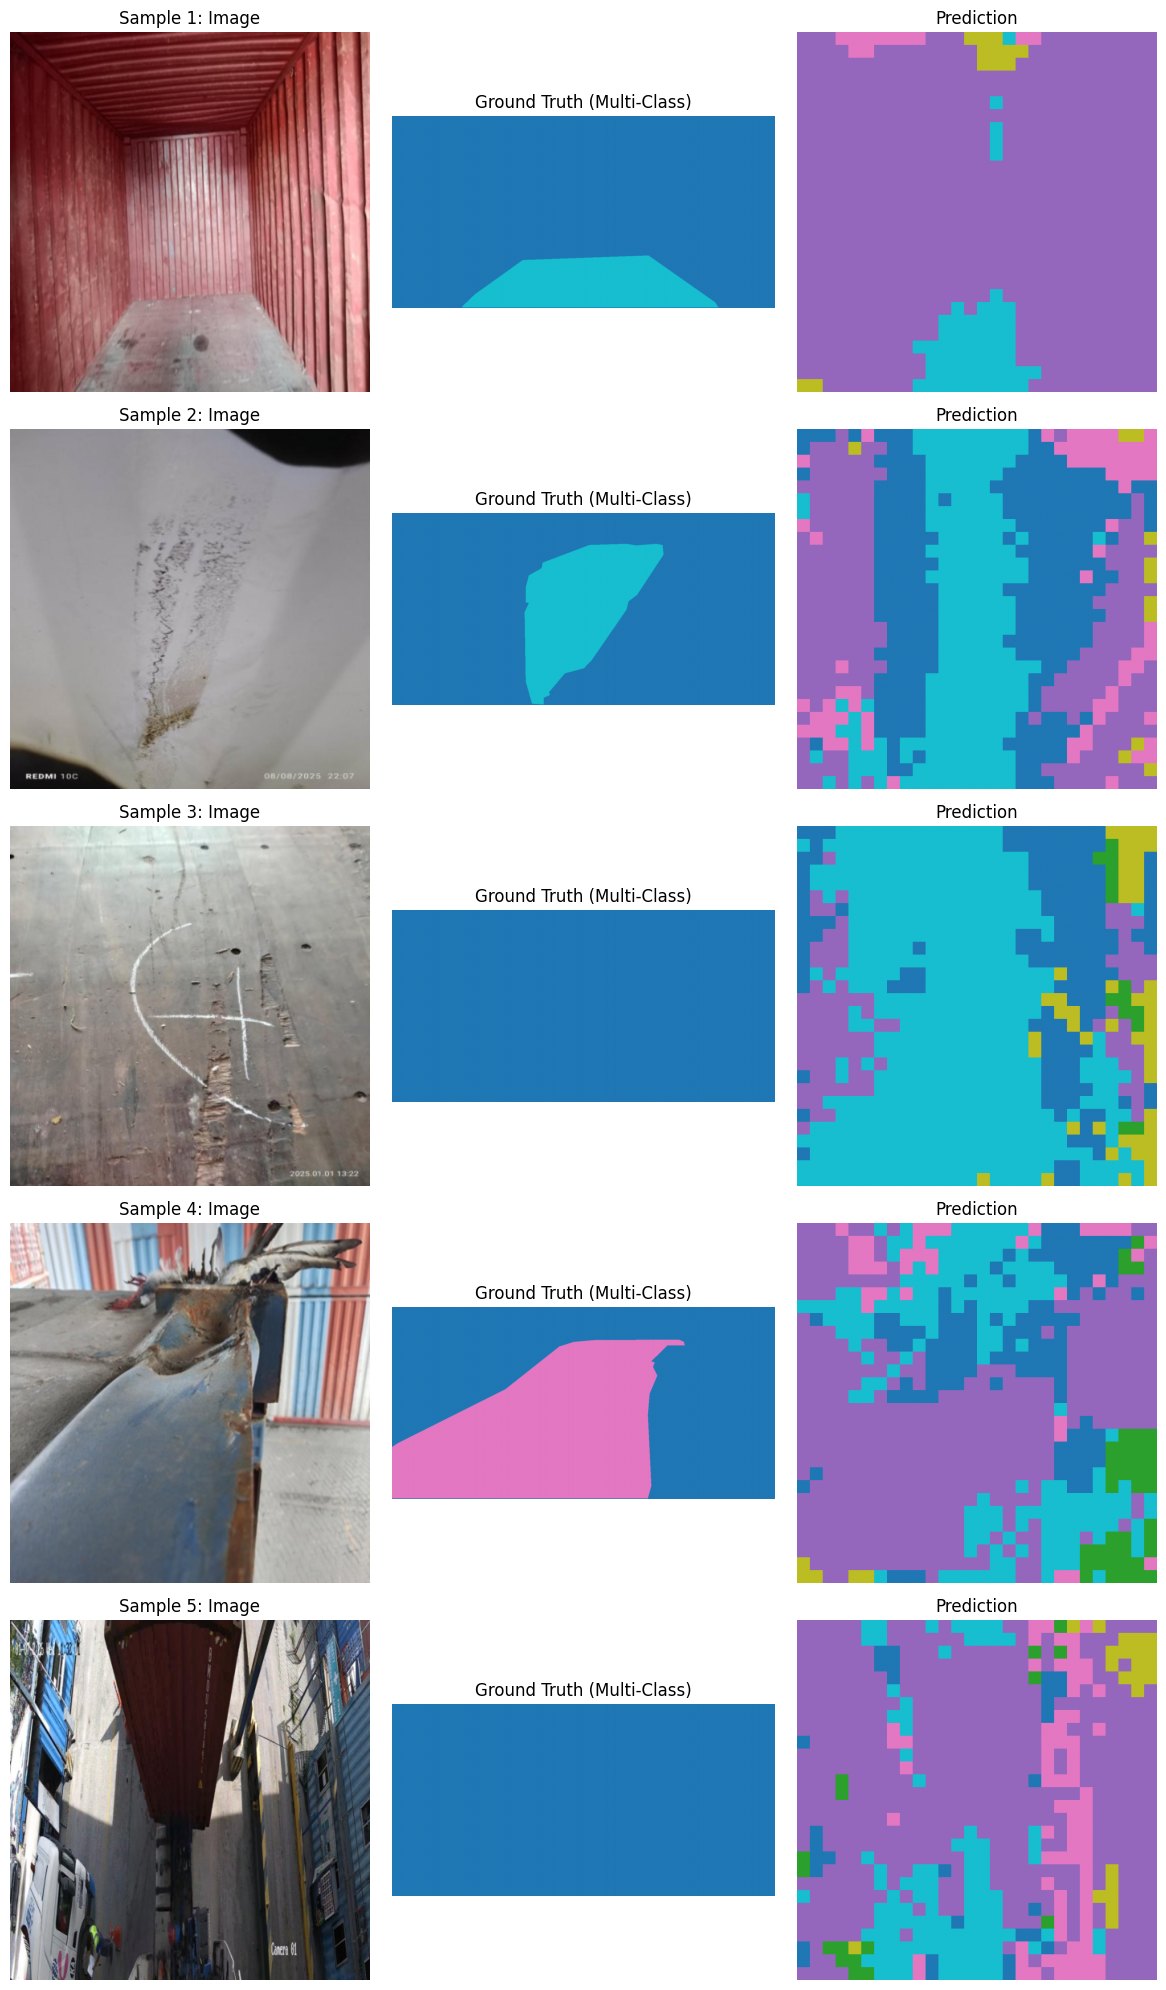

In [13]:
# @title 14. Batch Inference Demo
import random
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

print("Running multi-class batch inference on 5 random samples...")

fig, axes = plt.subplots(5, 3, figsize=(12, 20))

# Use a discrete colormap suitable for 6 distinct classes
cmap = plt.cm.get_cmap('tab10', 6)

for i in range(5):
    # Get random sample
    idx = random.randint(0, len(full_test) - 1)
    img_pil, mask = full_test[idx]

    # Convert for display
    img_display = img_pil.permute(1, 2, 0).numpy()
    img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_display = np.clip(img_display, 0, 1)

    # Get prediction
    pred = predict_segmentation(Image.fromarray((img_display * 255).astype(np.uint8)))

    # Plot - use 2D indexing
    axes[i, 0].imshow(img_display)
    axes[i, 0].set_title(f"Sample {i+1}: Image")
    axes[i, 0].axis('off')

    # Remove the > 0 squashing step and apply multi-class colormap
    axes[i, 1].imshow(mask.squeeze().numpy(), cmap=cmap, vmin=0, vmax=5)
    axes[i, 1].set_title("Ground Truth (Multi-Class)")
    axes[i, 1].axis('off')

    # Apply multi-class colormap to predictions
    axes[i, 2].imshow(pred, cmap=cmap, vmin=0, vmax=5)
    axes[i, 2].set_title("Prediction")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()